# Basecase

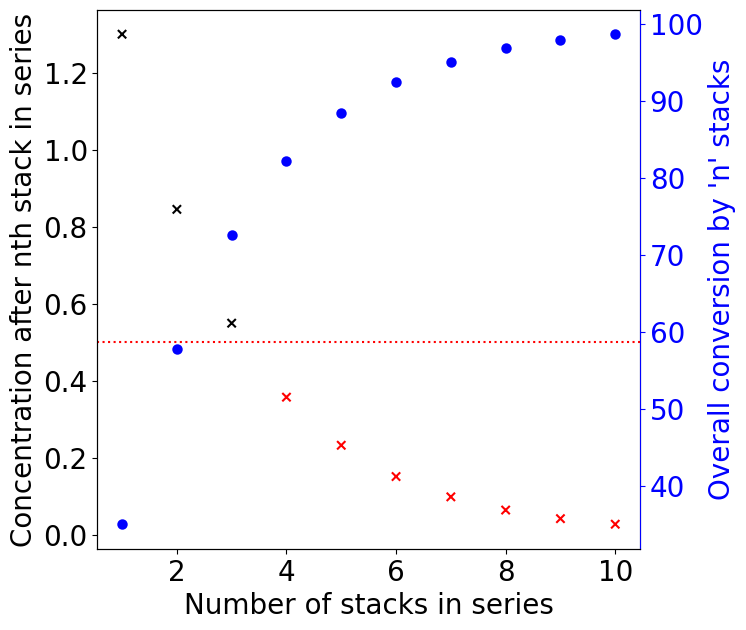

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#---------------------------------------------------------------- reation conditions
ethy = 2000000 ### TPA
FEC2H4 = 0.5      ### ethylene
FEC2H5OH = 0.2;
J = 0.5         ### A/cm2
V = 3.5       ### V
MW = 28       ### MW ethylene
n = 12        ### electrons per mol of C2H4
C0 = 120      ### 2M initial conc for [H]CO3

plt.rcParams.update({'font.size': 20})

#---------------------------------------------------------------- concentration variation with Nseries'
C0=120  # 2 M K2CO3 
Xdash = 0.35
stackseries=10
Cn = np.zeros(stackseries)
stacks = np.linspace(0, stackseries-1, stackseries)

conv = np.zeros(stackseries)
rate = np.zeros(stackseries)
prod = np.zeros(stackseries)

plt.rcParams.update({'font.size': 20})

stackseries=10
for i in range(stackseries):  ### 'i' refers to the no of stacks connected in series
    ### the increased of value kT when adding stacks for rate of prod euqal to 100 ||el stacks   
    rN = Xdash/(1-Xdash)
    Cn[i] = (C0/(1+rN)**(i+1))/60
    conv[i] = (1 - (1/(1+rN)**(i+1)))*100 

fig, ax = plt.subplots(figsize =(7,7))
ax2 = ax.twinx()
# plt.rcParams.update({'font.size': 15})
col = np.where(Cn<0.5,'r','k')
ax.scatter(stacks[ : 10]+1, Cn[ : 10], ls = '-', linewidth =1.5, c=col[:10], marker ='x', label= "Concentration")
ax2.scatter(stacks[:10]+1, conv[:10], ls = '-', linewidth =1.5, c='blue', label = "Conversion")
# ax.legend(loc=0, bbox_to_anchor=(1, 0.9))
# ax2.legend(loc=0, bbox_to_anchor=(0.963, 0.85))

ax.set_xlabel("Number of stacks in series", fontsize = 20)
ax.set_ylabel("Concentration after nth stack in series", fontsize = 20)
ax.axhline(y=0.5,color='r',ls=":", label='2-stack rate')
ax2.set_ylabel("Overall conversion by 'n' stacks", c= 'blue', fontsize = 20)

ax2.spines['right'].set_color('blue')
ax2.yaxis.label.set_color('blue') 
ax2.tick_params(axis='y', colors='blue')
plt.show()

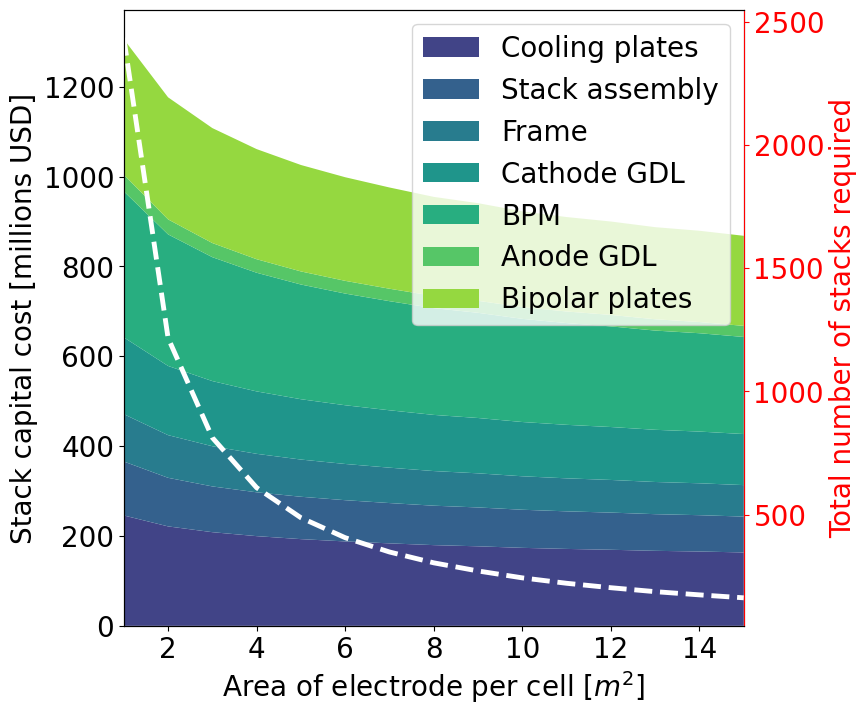

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#---------------------------------------------------------------- stack design parameters
cellperst = 150
areapercel = np.linspace(1,15,15)          ### m2
areaperst = areapercel* cellperst            ### m2
powerprst = areaperst*V*J*10000/1000     ### kWh
stacktot = np.zeros(len(areapercel))
cost = np.zeros(len(areapercel))
X = 0.58    ### conversion FOR n-stack system

Itot = (ethy*1000000/365/24/3600/MW)/(FEC2H4/(FEC2H4+FEC2H5OH)) * 96485* n/X
Atot = Itot/J/10000
power = Itot * V/1000 ### in kW

for o in range(len(areapercel)):
    stacktot[o] = round(Atot/areaperst[o])   ### No of stacks reqd
    
#---------------------------------------------------------------- observations: 1x rate and 40% conv(1-stack value)

part_coeff = [194.7371361, 95.1714818, 83.5651965, 135.5265756, 257.659476, 29.3912632, 239.0894003]

stackcost = np.zeros((len(areapercel), len(part_coeff)))

for i in range(len(stacktot)):  ### 'i' refers to the no of stacks connected in series
    for j in range(len(part_coeff)):
        stackcost[i,j] = part_coeff[j]*(areaperst[i]/0.0961)**0.85/1000000*stacktot[i]
    cost[i] = (sum(stackcost[i,:]))

#-------------------------------------------------------------------- colors for the stackplot
# user to specify
source = ['Cooling plates', 'Stack assembly', 'Frame', 'Cathode GDL', 'BPM', 'Anode GDL', 'Bipolar plates'] # list of units to be stacked
pct_max = 95 # for example, max percentile of color ramp
pct_min = 20 # for example, min percentile of color ramp
ramp = plt.cm.viridis # for example

# number of items in data source
n = len(source)

# list of values between 0.00 and 1.00; length equals length of data source
n_prop = list(i / 100.0 for i in (np.arange(pct_min, pct_max, (pct_max-pct_min)/n)))

# create list of colors
clr_lst = []
for i in n_prop:
    clr = ramp(i) 
    clr_lst.append(clr)
    
fig, ax = plt.subplots(figsize =(8,8))
ax2 = ax.twinx()

ax.stackplot(areapercel, stackcost[:,0], stackcost[:,1], stackcost[:,2], stackcost[:,3], stackcost[:,4], stackcost[:,5], stackcost[:,6], labels = ['Cooling plates', 'Stack assembly', 'Frame', 'Cathode GDL', 'BPM', 'Anode GDL', 'Bipolar plates'], colors =clr_lst)
# ax.scatter(areapercel, cost, c='red', label = 'Total cost of electrolyzer stacks')
ax.legend()
ax2.plot(areapercel, stacktot, ls = '--', linewidth =3.5, c='w')

ax.set_xlabel("Area of electrode per cell $[m^2]$", fontsize =20)
ax.set_ylabel("Stack capital cost [millions USD]", fontsize =20)
ax2.set_ylabel("Total number of stacks required", c = 'r', fontsize =20)

ax2.spines['right'].set_color('red')
ax2.yaxis.label.set_color('red') 
ax2.tick_params(axis='y', colors='red')
ax.margins(x=0)

plt.show()

# Optimisitic

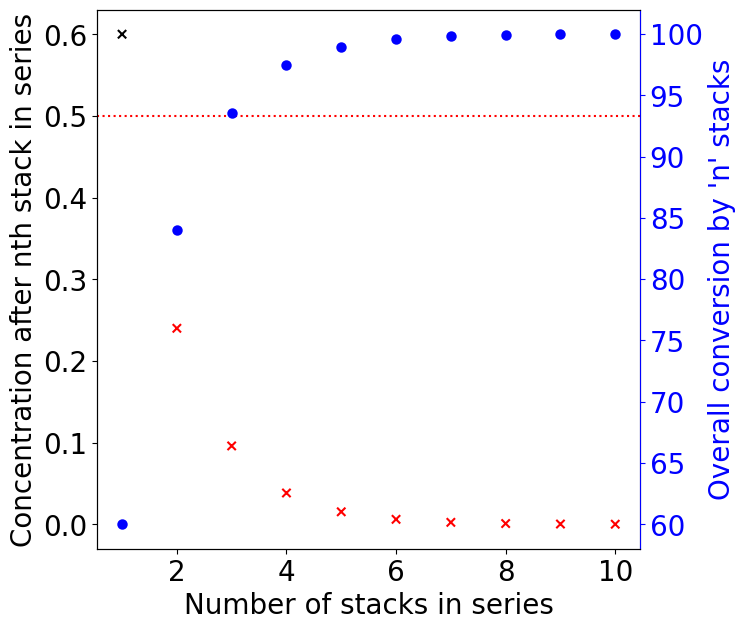

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#---------------------------------------------------------------- reation conditions
ethy = 2000000 ### TPA
FEC2H4 = 0.65      ### ethylene
FEC2H5OH = 0.25;
J = 1         ### A/cm2
V = 3.5       ### V
MW = 28       ### MW ethylene
n = 12        ### electrons per mol of C2H4
C0 = 90      ### 1.5 M initial conc for [H]CO3

plt.rcParams.update({'font.size': 20})

#---------------------------------------------------------------- stack design parameters
cellperst = 150
areapercel = 6                   ### m2
areaperst = cellperst* areapercel ### m2

X = 0.6
#---------------------------------------------------------------- concentration variation with Nseries'
C0=90  # 1.5 M K2CO3 
Xdash = X
stackseries=10
Cn = np.zeros(stackseries)
stacks = np.linspace(0, stackseries-1, stackseries)

conv = np.zeros(stackseries)
rate = np.zeros(stackseries)
prod = np.zeros(stackseries)

plt.rcParams.update({'font.size': 20})

for i in range(stackseries):  ### 'i' refers to the no of stacks connected in series
    ### the increased of value kT when adding stacks for rate of prod euqal to 100 ||el stacks   
    rN = Xdash/(1-Xdash)
    Cn[i] = (C0/(1+rN)**(i+1))/60
    conv[i] = (1 - (1/(1+rN)**(i+1)))*100 

fig, ax = plt.subplots(figsize =(7,7))
ax2 = ax.twinx()
# plt.rcParams.update({'font.size': 15})
col = np.where(Cn<0.5,'r','k')
ax.scatter(stacks[ : 10]+1, Cn[ : 10], ls = '-', linewidth =1.5, c=col[:10], marker ='x', label= "Concentration")
ax2.scatter(stacks[:10]+1, conv[:10], ls = '-', linewidth =1.5, c='blue', label = "Conversion")
# ax.legend(loc=0, bbox_to_anchor=(1, 0.9))
# ax2.legend(loc=0, bbox_to_anchor=(0.963, 0.85))

ax.set_xlabel("Number of stacks in series", fontsize = 20)
ax.set_ylabel("Concentration after nth stack in series", fontsize = 20)
ax.axhline(y=0.5,color='r',ls=":", label='2-stack rate')
ax2.set_ylabel("Overall conversion by 'n' stacks", c= 'blue', fontsize = 20)

ax2.spines['right'].set_color('blue')
ax2.yaxis.label.set_color('blue') 
ax2.tick_params(axis='y', colors='blue')
plt.show()

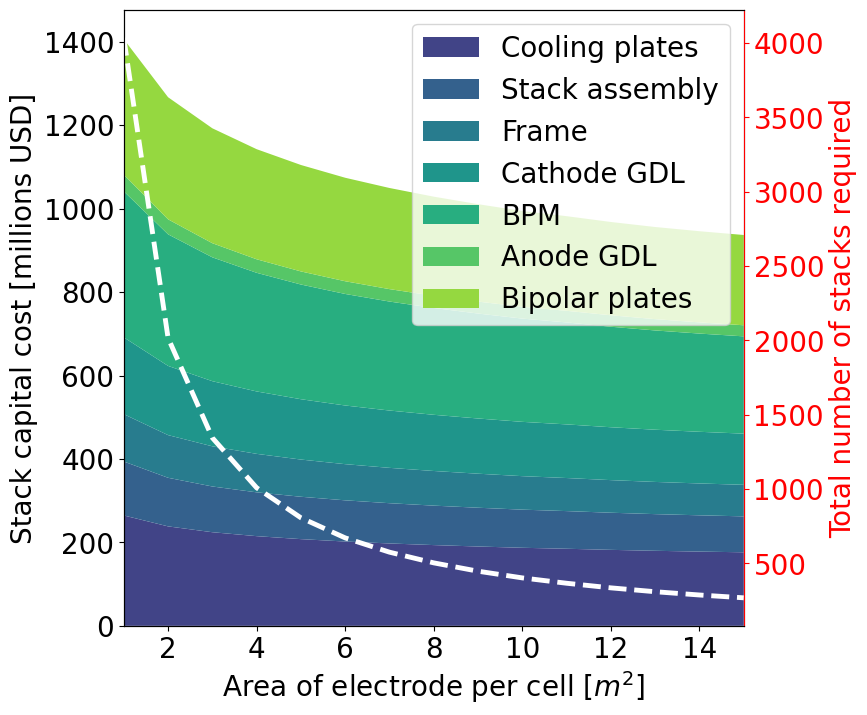

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#---------------------------------------------------------------- reation conditions
ethy = 2000000 ### TPA
FEC2H4 = 0.65      ### ethylene
FEC2H5OH = 0.25;
J = 1         ### A/cm2
V = 3.5       ### V
MW = 28       ### MW ethylene
n = 12        ### electrons per mol of C2H4
C0 = 90      ### 2M initial conc for [H]CO3
X = 0.6    ### conversion FOR n-stack system

plt.rcParams.update({'font.size': 20})

Itot = (ethy*1000000/365/24/3600/MW)/(FEC2H4/(FEC2H4+FEC2H5OH)) * 96485* n/X
Atot = Itot/J/10000
power = Itot * V/1000 ### in kW

#---------------------------------------------------------------- stack design parameters
cellperst = 150
areapercel = np.linspace(1,15,15)          ### m2
areaperst = areapercel* cellperst            ### m2
powerprst = areaperst*V*J*10000/1000     ### kWh
stacktot = np.zeros(len(areapercel))
cost = np.zeros(len(areapercel))


for o in range(len(areapercel)):
    stacktot[o] = round(Atot/areaperst[o])   ### No of stacks reqd
    
#---------------------------------------------------------------- observations: 1x rate and 40% conv(1-stack value)

part_coeff = [194.7371361, 95.1714818, 83.5651965, 135.5265756, 257.659476, 29.3912632, 239.0894003]

stackcost = np.zeros((len(areapercel), len(part_coeff)))

for i in range(len(stacktot)):  ### 'i' refers to the no of stacks connected in series
    for j in range(len(part_coeff)):
        stackcost[i,j] = part_coeff[j]*(areaperst[i]/0.0961)**0.85/1000000*stacktot[i]*0.65
    cost[i] = (sum(stackcost[i,:]))

#-------------------------------------------------------------------- colors for the stackplot
# user to specify
source = ['Cooling plates', 'Stack assembly', 'Frame', 'Cathode GDL', 'BPM', 'Anode GDL', 'Bipolar plates'] # list of units to be stacked
pct_max = 95 # for example, max percentile of color ramp
pct_min = 20 # for example, min percentile of color ramp
ramp = plt.cm.viridis # for example

# number of items in data source
n = len(source)

# list of values between 0.00 and 1.00; length equals length of data source
n_prop = list(i / 100.0 for i in (np.arange(pct_min, pct_max, (pct_max-pct_min)/n)))

# create list of colors
clr_lst = []
for i in n_prop:
    clr = ramp(i) 
    clr_lst.append(clr)
    
fig, ax = plt.subplots(figsize =(8,8))
ax2 = ax.twinx()

ax.stackplot(areapercel, stackcost[:,0], stackcost[:,1], stackcost[:,2], stackcost[:,3], stackcost[:,4], stackcost[:,5], stackcost[:,6], labels = ['Cooling plates', 'Stack assembly', 'Frame', 'Cathode GDL', 'BPM', 'Anode GDL', 'Bipolar plates'], colors =clr_lst)
# ax.scatter(areapercel, cost, c='red', label = 'Total cost of electrolyzer stacks')
ax.legend()
ax2.plot(areapercel, stacktot, ls = '--', linewidth =3.5, c='w')

ax.set_xlabel("Area of electrode per cell $[m^2]$", fontsize =20)
ax.set_ylabel("Stack capital cost [millions USD]", fontsize =20)
ax2.set_ylabel("Total number of stacks required", c = 'r', fontsize =20)

ax2.spines['right'].set_color('red')
ax2.yaxis.label.set_color('red') 
ax2.tick_params(axis='y', colors='red')
ax.margins(x=0)

plt.show()

# pessimistic

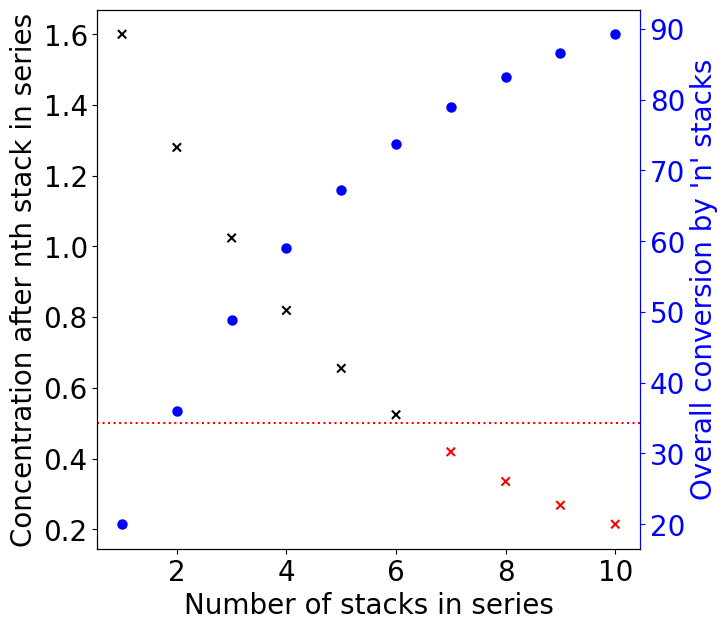

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#---------------------------------------------------------------- reation conditions
ethy = 2000000 ### TPA
FEC2H4 = 0.34      ### ethylene
FEC2H5OH = 0.13;
J = 0.3         ### A/cm2
V = 3.5       ### V
MW = 28       ### MW ethylene
n = 12        ### electrons per mol of C2H4
C0 = 120      ### 2M initial conc for [H]CO3

plt.rcParams.update({'font.size': 20})

#---------------------------------------------------------------- concentration variation with Nseries'
C0=120  # 2 M K2CO3 
Xdash = 0.2
stackseries=10
Cn = np.zeros(stackseries)
stacks = np.linspace(0, stackseries-1, stackseries)

conv = np.zeros(stackseries)
rate = np.zeros(stackseries)
prod = np.zeros(stackseries)

plt.rcParams.update({'font.size': 20})

stackseries=10
for i in range(stackseries):  ### 'i' refers to the no of stacks connected in series
    ### the increased of value kT when adding stacks for rate of prod euqal to 100 ||el stacks   
    rN = Xdash/(1-Xdash)
    Cn[i] = (C0/(1+rN)**(i+1))/60
    conv[i] = (1 - (1/(1+rN)**(i+1)))*100 

fig, ax = plt.subplots(figsize =(7,7))
ax2 = ax.twinx()
# plt.rcParams.update({'font.size': 15})
col = np.where(Cn<0.5,'r','k')
ax.scatter(stacks[ : 10]+1, Cn[ : 10], ls = '-', linewidth =1.5, c=col[:10], marker ='x', label= "Concentration")
ax2.scatter(stacks[:10]+1, conv[:10], ls = '-', linewidth =1.5, c='blue', label = "Conversion")
# ax.legend(loc=0, bbox_to_anchor=(1, 0.9))
# ax2.legend(loc=0, bbox_to_anchor=(0.963, 0.85))

ax.set_xlabel("Number of stacks in series", fontsize = 20)
ax.set_ylabel("Concentration after nth stack in series", fontsize = 20)
ax.axhline(y=0.5,color='r',ls=":", label='2-stack rate')
ax2.set_ylabel("Overall conversion by 'n' stacks", c= 'blue', fontsize = 20)

ax2.spines['right'].set_color('blue')
ax2.yaxis.label.set_color('blue') 
ax2.tick_params(axis='y', colors='blue')
plt.show()

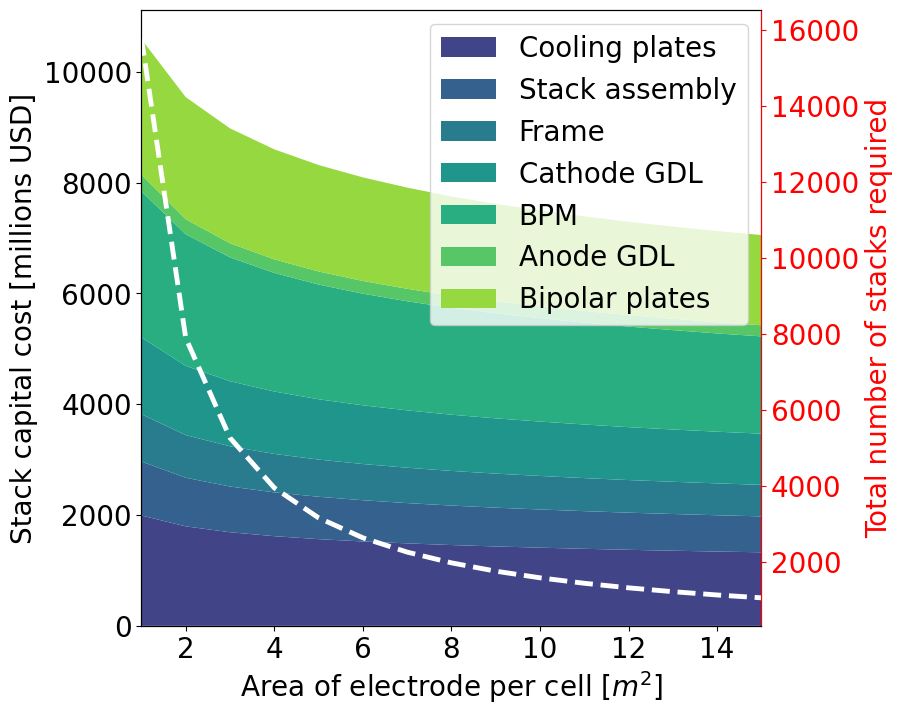

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#---------------------------------------------------------------- reation conditions
ethy = 2000000 ### TPA
FEC2H4 = 0.34      ### ethylene
FEC2H5OH = 0.13;
J = 0.3         ### A/cm2
V = 3.5       ### V
MW = 28       ### MW ethylene
n = 12        ### electrons per mol of C2H4
C0 = 90      ### 2M initial conc for [H]CO3
X = 0.51    ### conversion FOR n-stack system

plt.rcParams.update({'font.size': 20})

Itot = (ethy*1000000/365/24/3600/MW)/(FEC2H4/(FEC2H4+FEC2H5OH)) * 96485* n/X
Atot = Itot/J/10000
power = Itot * V/1000 ### in kW

#---------------------------------------------------------------- stack design parameters
cellperst = 150
areapercel = np.linspace(1,15,15)          ### m2
areaperst = areapercel* cellperst            ### m2
powerprst = areaperst*V*J*10000/1000     ### kWh
stacktot = np.zeros(len(areapercel))
cost = np.zeros(len(areapercel))


for o in range(len(areapercel)):
    stacktot[o] = round(Atot/areaperst[o])   ### No of stacks reqd
    
#---------------------------------------------------------------- observations: 1x rate and 40% conv(1-stack value)

part_coeff = [194.7371361, 95.1714818, 83.5651965, 135.5265756, 257.659476, 29.3912632, 239.0894003]

stackcost = np.zeros((len(areapercel), len(part_coeff)))

for i in range(len(stacktot)):  ### 'i' refers to the no of stacks connected in series
    for j in range(len(part_coeff)):
        stackcost[i,j] = part_coeff[j]*(areaperst[i]/0.0961)**0.85/1000000*stacktot[i]*1.25
    cost[i] = (sum(stackcost[i,:]))

#-------------------------------------------------------------------- colors for the stackplot
# user to specify
source = ['Cooling plates', 'Stack assembly', 'Frame', 'Cathode GDL', 'BPM', 'Anode GDL', 'Bipolar plates'] # list of units to be stacked
pct_max = 95 # for example, max percentile of color ramp
pct_min = 20 # for example, min percentile of color ramp
ramp = plt.cm.viridis # for example

# number of items in data source
n = len(source)

# list of values between 0.00 and 1.00; length equals length of data source
n_prop = list(i / 100.0 for i in (np.arange(pct_min, pct_max, (pct_max-pct_min)/n)))

# create list of colors
clr_lst = []
for i in n_prop:
    clr = ramp(i) 
    clr_lst.append(clr)
    
fig, ax = plt.subplots(figsize =(8,8))
ax2 = ax.twinx()

ax.stackplot(areapercel, stackcost[:,0], stackcost[:,1], stackcost[:,2], stackcost[:,3], stackcost[:,4], stackcost[:,5], stackcost[:,6], labels = ['Cooling plates', 'Stack assembly', 'Frame', 'Cathode GDL', 'BPM', 'Anode GDL', 'Bipolar plates'], colors =clr_lst)
# ax.scatter(areapercel, cost, c='red', label = 'Total cost of electrolyzer stacks')
ax.legend()
ax2.plot(areapercel, stacktot, ls = '--', linewidth =3.5, c='w')

ax.set_xlabel("Area of electrode per cell $[m^2]$", fontsize =20)
ax.set_ylabel("Stack capital cost [millions USD]", fontsize =20)
ax2.set_ylabel("Total number of stacks required", c = 'r', fontsize =20)

ax2.spines['right'].set_color('red')
ax2.yaxis.label.set_color('red') 
ax2.tick_params(axis='y', colors='red')
ax.margins(x=0)

plt.show()

# Econometrics

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


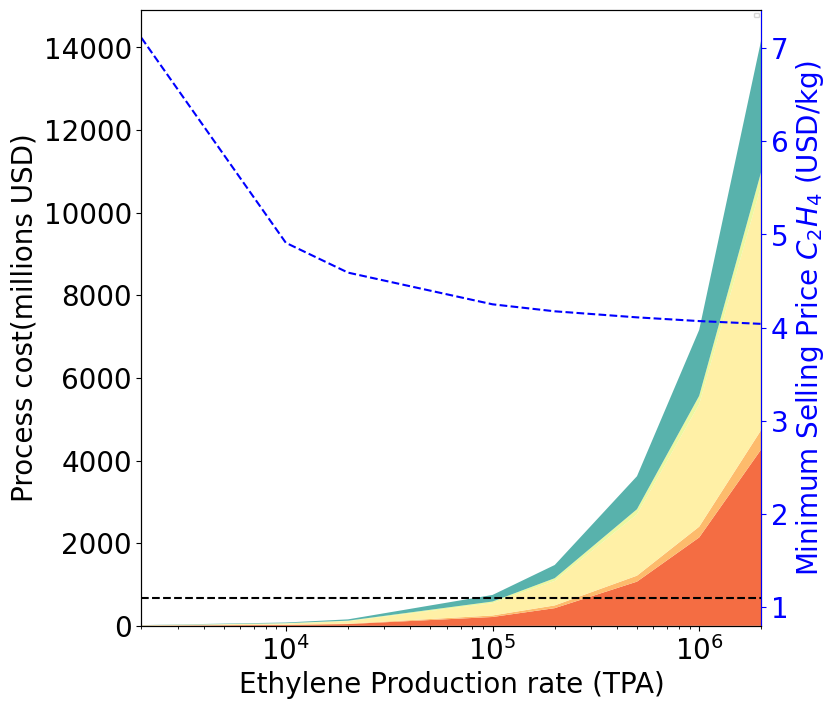

In [5]:
#----------------------------------------------------------------------------------------- basecase scenario

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# user to specify
source = ['Carbon Capture Unit', 'GO membrane concentrator', 'Electrolyzer', 'Cathode product separation', 'Anode product separation', 'Balance of Plant'] # list of units to be stacked
pct_max = 95 # for example, max percentile of color ramp
pct_min = 20 # for example, min percentile of color ramp
ramp = plt.cm.Spectral # for example

plt.rcParams.update({'font.size': 20})

# number of items in data source
n = len(source)

# list of values between 0.00 and 1.00; length equals length of data source
n_prop = list(i / 100.0 for i in (np.arange(pct_min, pct_max, (pct_max-pct_min)/n)))

# create list of colors
clr_lst = []
for j in n_prop:
    clr = ramp(j) 
    clr_lst.append(clr)

fig, ax = plt.subplots(figsize =(8,8))
ax2 = ax.twinx()

prodrate = [2000, 10000, 20000, 100000, 200000, 500000, 1000000, 2000000]

CCU = np.zeros(len(prodrate))
GO =  np.zeros(len(prodrate))
elec =  np.zeros(len(prodrate))
cath_sep =  np.zeros(len(prodrate))
zhf_sep =  np.zeros(len(prodrate))
anod_sep =  np.zeros(len(prodrate))
pervap =  np.zeros(len(prodrate))
distl =  np.zeros(len(prodrate))
bop =  np.zeros(len(prodrate))


CCU= [4.277692629669879,21.388463148349384,42.776926296698770,2.138846314834939e+02,4.277692629669877e+02,1.069423157417470e+03,2.138846314834940e+03,4.277692629669880e+03]
GO= [1.324402805800570,5.201691550187343,9.376053831930380,36.825156046217210,66.377377844738550,1.446335678246688e+02,2.607021398220753e+02,4.699158482365573e+02]
elec= [5.933501379494370,29.667506897471846,59.335013794943690,2.966750689747184e+02,5.933501379494369e+02,1.483375344873592e+03,2.963783939057437e+03,5.927567878114874e+03]
zhf_sep= [0.011766215310369,0.046212694876191,0.083298425271321,0.327160825226301,0.589707690166689,1.284948727591433,2.316121270345954,4.174810732724149]
distl = [2.537379034370517,7.828243933812038,12.717019788999984,39.234159213467310,63.736079680321794,1.210440240502880e+02,1.966365971988964e+02,3.194370945722788e+02]
pervap=[0.022317683575113,0.087654379441039,0.157997100042204,0.620545484080914,1.118533809197971,2.437239023440022,4.393125594736977,7.918612949128356]
bop=[3.194962281266199,15.974811406330993,31.949622812661985,1.597481140633099e+02,3.194962281266198e+02,7.987405703165496e+02,1.595883659492466e+03,3.191767318984932e+03]

for pp in range(len(prodrate)):
    cath_sep[pp] =distl[pp]+pervap[pp]+zhf_sep[pp] #5
    anod_sep[pp] = bop[pp]/10000
    
breakeven =[7.110000000000000,4.910000000000000,4.590000000000000,4.250000000000000,4.175000000000000,4.110000000000000,4.070000000000000,4.040000000000000]

ax.stackplot(prodrate, CCU, GO, elec, cath_sep, anod_sep, bop, colors =clr_lst)
ax.margins(x=0)
ax.legend(fontsize=4)
ax.set_xscale('log')
# ax.set_yscale('log')

ax2.plot(prodrate, breakeven, ls = '--', linewidth =1.5, c='blue')

ax2.margins(x=0)
ax2.yaxis.label.set_color('blue')
ax2.tick_params(axis='y', colors='blue')
ax2.axhline(y=1.1,color='k',ls="--", label='2-stack rate')
ax2.set_ylabel("Minimum Selling Price $C_{2}H_{4}$ (USD/kg)", c = 'blue', fontsize =20)
ax2.spines['right'].set_color('blue')

ax.set_xlabel("Ethylene Production rate (TPA)", fontsize =20)
ax.set_ylabel("Process cost(millions USD)", fontsize =20)

plt.show()

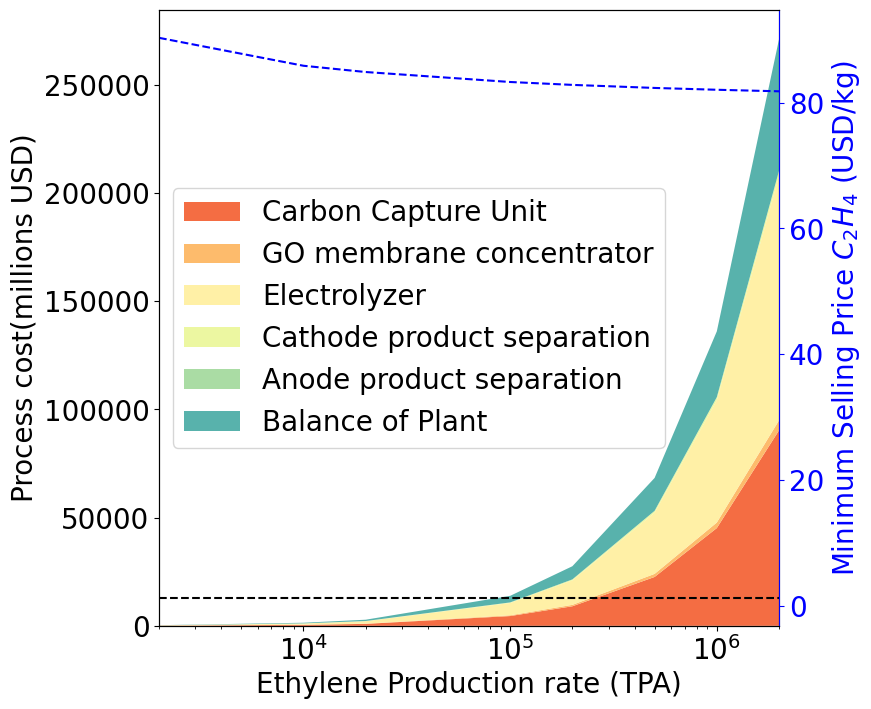

In [6]:
#----------------------------------------------------------------------------------------- pessimistic case scenario

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# user to specify
source = ['Carbon Capture Unit', 'GO membrane concentrator', 'Electrolyzer', 'Cathode product separation', 'Anode product separation', 'Balance of Plant'] # list of units to be stacked
pct_max = 95 # for example, max percentile of color ramp
pct_min = 20 # for example, min percentile of color ramp
ramp = plt.cm.Spectral # for example

plt.rcParams.update({'font.size': 20})

# number of items in data source
n = len(source)

# list of values between 0.00 and 1.00; length equals length of data source
n_prop = list(i / 100.0 for i in (np.arange(pct_min, pct_max, (pct_max-pct_min)/n)))

# create list of colors
clr_lst = []
for j in n_prop:
    clr = ramp(j) 
    clr_lst.append(clr)

fig, ax = plt.subplots(figsize =(8,8))
ax2 = ax.twinx()

prodrate = [2000, 10000, 20000, 100000, 200000, 500000, 1000000, 2000000]

CCU = np.zeros(len(prodrate))
GO =  np.zeros(len(prodrate))
elec =  np.zeros(len(prodrate))
cath_sep =  np.zeros(len(prodrate))
zhf_sep =  np.zeros(len(prodrate))
anod_sep =  np.zeros(len(prodrate))
pervap =  np.zeros(len(prodrate))
distl =  np.zeros(len(prodrate))
bop =  np.zeros(len(prodrate))

CCU=[90.311539707993290,4.515576985399666e+02,9.031153970799331e+02,4.515576985399666e+03,9.031153970799332e+03,2.257788492699833e+04,4.515576985399666e+04,9.031153970799332e+04]
GO= [13.010893740441597,51.101262949326290,92.110073746155990,3.617692368168088e+02,6.520893840790319e+02,1.420875864975389e+03,2.561130061243266e+03,4.616439305003995e+03]
elec= [1.127591564823785e+02,5.637957824118927e+02,1.129179721957340e+03,5.645898609786699e+03,1.129179721957340e+04,2.822949304893350e+04,5.645898609786699e+04,1.129179721957340e+05]
zhf_sep= [0.157837313770709,0.619917911491496,1.117402609024900,4.388682721046234,7.910604665190152,17.236881201501276,31.069494313641890,56.002792246508630]
distl = [18.021682895912924,55.599943049901410,90.322373959105280,2.786598164701396e+02,4.526842073921193e+02,8.597127147070961e+02,1.396607425397527e+03,2.268795456096107e+03]
pervap= [0.167600742196715,0.658264510367595,1.186522388978173,4.660155851244273,8.399935233544936,18.303112321874394,32.991376894614560,59.466987376879270]
bop= [60.716468875126900,3.035823443756344e+02,6.080198502847215e+02,3.040099251423607e+03,6.080198502847214e+03,1.520049625711804e+04,3.040099251423607e+04,6.080198502847214e+04]

for pp in range(len(prodrate)):
    cath_sep[pp] =distl[pp]+pervap[pp]+zhf_sep[pp] #5
    anod_sep[pp] = bop[pp]/10000

breakeven = [90.300000000000000,85.860000000000000,84.865000000000000,83.280000000000000,82.820000000000010,82.335000000000010,82.045000000000000,81.800000000000000]

ax.stackplot(prodrate, CCU, GO, elec, cath_sep, anod_sep, bop, labels=source, colors =clr_lst)
ax.margins(x=0)
ax.legend(fontsize=4)
ax.set_xscale('log')
ax.legend(loc='center left')
# ax.set_yscale('log')

ax2.plot(prodrate, breakeven, ls = '--', linewidth =1.5, c='blue')

ax2.margins(x=0)
ax2.yaxis.label.set_color('blue')
ax2.tick_params(axis='y', colors='blue')
ax2.axhline(y=1.3,color='k',ls="--", label='2-stack rate')
ax2.set_ylabel("Minimum Selling Price $C_{2}H_{4}$ (USD/kg)", c = 'blue', fontsize =20)
ax2.spines['right'].set_color('blue')

ax.set_xlabel("Ethylene Production rate (TPA)", fontsize =20)
ax.set_ylabel("Process cost(millions USD)", fontsize =20)

plt.show()

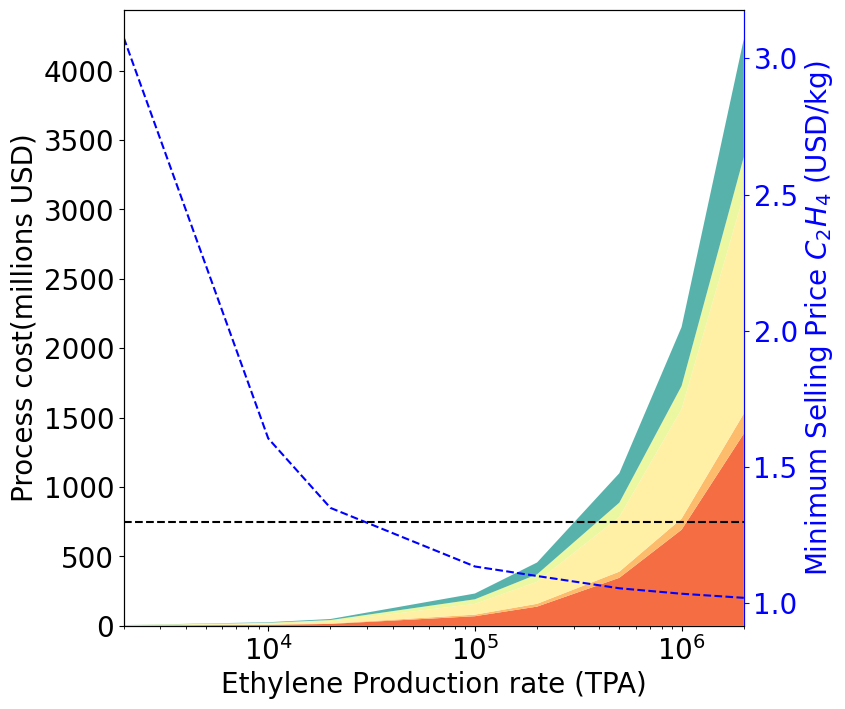

In [8]:
#----------------------------------------------------------------------------------------- optimistic case scenario

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# user to specify
source = ['Carbon Capture Unit', 'GO membrane concentrator', 'Electrolyzer', 'Cathode product separation', 'Anode product separation', 'Balance of Plant'] # list of units to be stacked
pct_max = 95 # for example, max percentile of color ramp
pct_min = 20 # for example, min percentile of color ramp
ramp = plt.cm.Spectral # for example

plt.rcParams.update({'font.size': 20})

# number of items in data source
n = len(source)

# list of values between 0.00 and 1.00; length equals length of data source
n_prop = list(i / 100.0 for i in (np.arange(pct_min, pct_max, (pct_max-pct_min)/n)))

# create list of colors
clr_lst = []
for j in n_prop:
    clr = ramp(j) 
    clr_lst.append(clr)

fig, ax = plt.subplots(figsize =(8,8))
ax2 = ax.twinx()

prodrate = [2000, 10000, 20000, 100000, 200000, 500000, 1000000, 2000000]

CCU = np.zeros(len(prodrate))
GO =  np.zeros(len(prodrate))
elec =  np.zeros(len(prodrate))
cath_sep =  np.zeros(len(prodrate))
zhf_sep =  np.zeros(len(prodrate))
anod_sep =  np.zeros(len(prodrate))
pervap =  np.zeros(len(prodrate))
distl =  np.zeros(len(prodrate))
bop =  np.zeros(len(prodrate))

CCU= [1.384358012546118,6.921790062730588,13.843580125461177,69.217900627305910,1.384358012546118e+02,3.460895031365296e+02,6.921790062730591e+02,1.384358012546118e+03]
GO= [0.405545693656544,1.592811189064908,2.871043641992910,11.276239666183878,20.325432431317626,44.288278711415240,79.829663353800750,1.438930420553595e+02]
elec=[1.05,7.036278750109068,14.072557500218135,77.399066251199740,1.583162718774540e+02,3.940316100061078e+02,7.880632200122157e+02,1.576126440024431e+03]
zhf_sep= [0.002947849715261,0.011577901291011,0.020869177789172,0.081965264109869,0.147742464394077,0.321924734576093,0.580269631925145,1.045936548423106]
distl = [2.118911931656174,6.537202069766629,10.619716093265776,32.763622210088165,53.224661306908980,1.010813218449490e+02,1.642070917908314e+02,2.667552076115822e+02]
pervap= [0.015859051086664,0.062287614968940,0.112273483611364,0.440962544366031,0.794835394207869,1.731913531843794,3.121775743552353,5.627003666087653]
bop= [0.335,3.788765480827959,7.577530961655918,41.676420289107550,85.247223318629080,2.121708669263657e+02,4.243417338527315e+02,8.486834677054629e+02]

for pp in range(len(prodrate)):
    cath_sep[pp] =distl[pp]+pervap[pp]+zhf_sep[pp] #5
    anod_sep[pp] = bop[pp]/10000
    
breakeven = [3.075000000000000,1.605000000000000,1.350000000000000,1.135000000000000,1.100000000000000,1.055000000000000,1.035000000000000,1.020000000000000]

ax.stackplot(prodrate, CCU, GO, elec, cath_sep, anod_sep, bop, labels=source, colors =clr_lst)
ax.margins(x=0)
#ax.legend(fontsize=4)
ax.set_xscale('log')
#ax.legend(loc='center left')
# ax.set_yscale('log')

ax2.plot(prodrate, breakeven, ls = '--', linewidth =1.5, c='blue')

ax2.margins(x=0)
ax2.yaxis.label.set_color('blue')
ax2.tick_params(axis='y', colors='blue')
ax2.axhline(y=1.3,color='k',ls="--", label='2-stack rate')
ax2.set_ylabel("Minimum Selling Price $C_{2}H_{4}$ (USD/kg)", c = 'blue', fontsize =20)
ax2.spines['right'].set_color('blue')

ax.set_xlabel("Ethylene Production rate (TPA)", fontsize =20)
ax.set_ylabel("Process cost(millions USD)", fontsize =20)

plt.show()